# LG전자 연결재무제표 데이터 분석 및 시각화

DART API를 사용하여 LG전자의 **연결재무제표(Consolidated)** 기반 주요 재무지표를 가져와 시각화합니다.

## 주요 분석 지표
- **매출액 (Sales/Revenue)**
- **매출총이익 (Gross Margin)**
- **영업이익 (Operating Profit)**
- **당기순이익 (Net Income)**

## 연결재무제표 vs 개별재무제표
- **연결재무제표**: 모회사와 자회사를 하나의 기업으로 보는 관점 (그룹 전체 성과)
- **개별재무제표**: 모회사 단독 기준 (LG전자 단독 성과)

이 노트북은 연결재무제표 기준으로 LG전자 그룹 전체의 재무성과를 분석합니다.

In [1]:
# 필요한 라이브러리 import
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from datetime import datetime, timedelta
import json

# 한글 폰트 설정 (Windows 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경고 무시
warnings.filterwarnings('ignore')

print("라이브러리 import 완료!")
print("연결재무제표 분석을 위한 환경 설정 완료!")

라이브러리 import 완료!
연결재무제표 분석을 위한 환경 설정 완료!


In [2]:
# DART API 설정
# DART API 키가 필요합니다. https://opendart.fss.or.kr/ 에서 발급받으세요.
API_KEY = "xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  # 실제 API 키로 변경해주세요

# LG전자 회사 정보
COMPANY_CODE = "066570"     # LG전자 종목코드
LG_CORP_CODE = "00126380"   # LG전자 고유번호 (DART용)

# 기본 URL
BASE_URL = "https://opendart.fss.or.kr/api"

# 분석 대상 연도 설정 (최근 10년)
years = list(range(2015, 2025))
print(f"분석 대상 연도: {years}")

# 연결재무제표 재무지표 매핑 (IFRS 기준)
consolidated_financial_items = {
    # 매출액 관련
    'ifrs-full_Revenue': '매출액',
    'dart_Revenue': '매출액',
    
    # 매출총이익 관련  
    'ifrs-full_GrossProfit': '매출총이익',
    'dart_GrossProfit': '매출총이익',
    
    # 영업이익 관련
    'ifrs-full_ProfitLossFromOperatingActivities': '영업이익',
    'dart_ProfitLossFromOperatingActivities': '영업이익',
    
    # 당기순이익 관련
    'ifrs-full_ProfitLoss': '당기순이익',
    'ifrs-full_ProfitLossAttributableToOwnersOfParent': '지배주주순이익',
    'dart_ProfitLoss': '당기순이익'
}

print("연결재무제표 분석을 위한 API 설정 완료!")
print("재무지표:", list(set(consolidated_financial_items.values())))

분석 대상 연도: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
연결재무제표 분석을 위한 API 설정 완료!
재무지표: ['지배주주순이익', '당기순이익', '매출액', '매출총이익', '영업이익']


In [12]:
def get_consolidated_financial_data(corp_code, bsns_year, reprt_code="11011"):
    """
    연결재무제표 데이터를 가져오는 함수
    
    Parameters:
    - corp_code: 회사 고유번호
    - bsns_year: 사업연도
    - reprt_code: 보고서 코드 (11011: 사업보고서, 11012: 반기보고서, 11013: 1분기, 11014: 3분기)
    
    Returns:
    - DataFrame: 연결재무제표 데이터
    """
    url = f"{BASE_URL}/fnlttSinglAcntAll.json"
    
    params = {
        'crtfc_key': API_KEY,
        'corp_code': corp_code,
        'bsns_year': str(bsns_year),
        'reprt_code': reprt_code,
        'fs_div': 'CFS'  # CFS: 연결재무제표 (Consolidated Financial Statements)
    }
    
    try:
        response = requests.get(url, params=params)
        data = response.json()
        
        if data['status'] == '000':
            return pd.DataFrame(data['list'])
        else:
            print(f"{bsns_year}년 연결재무제표 조회 실패: {data['message']}")
            return None
            
    except Exception as e:
        print(f"{bsns_year}년 연결재무제표 조회 중 오류 발생: {str(e)}")
        return None

def extract_consolidated_metrics(df, year):
    """
    연결재무제표에서 주요 재무지표를 추출하는 함수
    
    Parameters:
    - df: 연결재무제표 DataFrame
    - year: 해당 연도
    
    Returns:
    - dict: 추출된 재무지표
    """
    if df is None or len(df) == 0:
        return None
    
    # 추출할 지표들
    metrics = {
        '매출액': 0,
        '매출총이익': 0, 
        '영업이익': 0,
        '당기순이익': 0
    }
    
    # Account ID 기반 매핑
    for _, row in df.iterrows():
        account_id = str(row.get('account_id', ''))
        account_nm = str(row.get('account_nm', ''))
        amount = row.get('thstrm_amount', 0)
        
        # 숫자로 변환 시도 (DART 데이터는 백만원 단위)
        try:
            amount = float(amount) if amount != '' else 0
        except:
            amount = 0
        
        # 매출액 식별
        if any(keyword in account_id for keyword in ['Revenue', 'revenue']) or \
           any(keyword in account_nm for keyword in ['매출액', '수익(매출액)', '매출']):
            if '매출총' not in account_nm and '매출원가' not in account_nm:
                metrics['매출액'] = max(metrics['매출액'], amount)
        
        # 매출총이익 식별
        elif any(keyword in account_id for keyword in ['GrossProfit', 'grossprofit']) or \
             '매출총이익' in account_nm:
            metrics['매출총이익'] = max(metrics['매출총이익'], amount)
        
        # 영업이익 식별
        elif any(keyword in account_id for keyword in ['Operating', 'operating']) or \
             '영업이익' in account_nm:
            metrics['영업이익'] = max(metrics['영업이익'], amount)
        
        # 당기순이익 식별 (지배주주 순이익 우선)
        elif any(keyword in account_id for keyword in ['ProfitLoss', 'profitloss']) or \
             any(keyword in account_nm for keyword in ['당기순이익', '지배주주순이익']):
            if '지배주주' in account_nm:  # 지배주주순이익 우선 선택
                metrics['당기순이익'] = amount
            elif metrics['당기순이익'] == 0:  # 지배주주순이익이 없을 때만
                metrics['당기순이익'] = amount
    
    # 연도 정보 추가
    metrics['year'] = year
    
    return metrics

print("연결재무제표 데이터 수집 함수 정의 완료!")

연결재무제표 데이터 수집 함수 정의 완료!


In [13]:
# LG전자 연결재무제표 데이터 수집 실행
print("=== LG전자 연결재무제표 데이터 수집 시작 ===")
print("연결재무제표는 LG전자와 자회사를 포함한 그룹 전체의 재무성과를 보여줍니다.\n")

# 수집된 데이터를 저장할 리스트
consolidated_data_list = []

# 보고서 코드 우선순위 (사업보고서 > 반기보고서 > 분기보고서)
report_priority = ["11011", "11012", "11013", "11014"]
report_names = {
    "11011": "사업보고서",
    "11012": "반기보고서", 
    "11013": "1분기보고서",
    "11014": "3분기보고서"
}

# 각 연도별 데이터 수집
for year in years:
    print(f"{year}년 연결재무제표 수집 중...")
    year_data_collected = False
    
    # 보고서 우선순위에 따라 시도
    for reprt_code in report_priority:
        if year_data_collected:
            break
            
        print(f"  → {report_names[reprt_code]} 시도...")
        
        # 연결재무제표 데이터 조회
        df = get_consolidated_financial_data(LG_CORP_CODE, year, reprt_code)
        
        if df is not None and len(df) > 0:
            # 주요 재무지표 추출
            metrics = extract_consolidated_metrics(df, year)
            
            if metrics and any(metrics[key] > 0 for key in ['매출액', '매출총이익', '영업이익', '당기순이익']):
                consolidated_data_list.append(metrics)
                print(f"    ✓ {report_names[reprt_code]} 데이터 수집 성공")
                print(f"    ✓ 매출액: {metrics['매출액']/1000000000000:.1f}조원")
                print(f"    ✓ 영업이익: {metrics['영업이익']/1000000000000:.1f}조원")
                print(f"    ✓ 당기순이익: {metrics['당기순이익']/1000000000000:.1f}조원")
                year_data_collected = True
            else:
                print(f"    → {report_names[reprt_code]} 유효한 재무지표 없음")
        else:
            print(f"    → {report_names[reprt_code]} 데이터 없음")
    
    if not year_data_collected:
        print(f"  ✗ {year}년 연결재무제표 수집 실패")
    print()

# 데이터 수집 결과 확인 및 DataFrame 생성
if consolidated_data_list:
    consolidated_df = pd.DataFrame(consolidated_data_list)
    
    print("=== 연결재무제표 데이터 수집 완료 ===")
    print(f"총 수집 연도: {len(consolidated_df)}년")
    print(f"수집된 연도: {sorted(consolidated_df['year'].tolist())}")
    print(f"데이터 형태: {consolidated_df.shape}")
    
    print("\n수집된 재무지표 요약 (단위: 조원):")
    for col in ['매출액', '매출총이익', '영업이익', '당기순이익']:
        if col in consolidated_df.columns:
            valid_data = consolidated_df[consolidated_df[col] > 0]
            if len(valid_data) > 0:
                avg_val = valid_data[col].mean() / 1000000000000
                print(f"  - {col}: {len(valid_data)}년치 데이터, 평균 {avg_val:.1f}조원")
            else:
                print(f"  - {col}: 데이터 없음")
    
    # 전역 변수로 설정
    globals()['consolidated_financial_data'] = consolidated_df
    
else:
    print("연결재무제표 데이터 수집 실패")
    print("API 키를 확인하거나 네트워크 연결을 점검해주세요.")
    consolidated_financial_data = None

=== LG전자 연결재무제표 데이터 수집 시작 ===
연결재무제표는 LG전자와 자회사를 포함한 그룹 전체의 재무성과를 보여줍니다.

2015년 연결재무제표 수집 중...
  → 사업보고서 시도...
    ✓ 사업보고서 데이터 수집 성공
    ✓ 매출액: 200.7조원
    ✓ 영업이익: 40.1조원
    ✓ 당기순이익: 1.1조원

2016년 연결재무제표 수집 중...
  → 사업보고서 시도...
    ✓ 사업보고서 데이터 수집 성공
    ✓ 매출액: 201.9조원
    ✓ 영업이익: 47.4조원
    ✓ 당기순이익: 0.0조원

2017년 연결재무제표 수집 중...
  → 사업보고서 시도...
    ✓ 사업보고서 데이터 수집 성공
    ✓ 매출액: 239.6조원
    ✓ 영업이익: 62.2조원
    ✓ 당기순이익: 56.2조원

2018년 연결재무제표 수집 중...
  → 사업보고서 시도...
    ✓ 사업보고서 데이터 수집 성공
    ✓ 매출액: 243.8조원
    ✓ 영업이익: 67.0조원
    ✓ 당기순이익: 61.2조원

2019년 연결재무제표 수집 중...
  → 사업보고서 시도...
    ✓ 사업보고서 데이터 수집 성공
    ✓ 매출액: 230.4조원
    ✓ 영업이익: 45.4조원
    ✓ 당기순이익: 30.4조원

2020년 연결재무제표 수집 중...
  → 사업보고서 시도...
    ✓ 사업보고서 데이터 수집 성공
    ✓ 매출액: 236.8조원
    ✓ 영업이익: 65.3조원
    ✓ 당기순이익: 36.3조원

2021년 연결재무제표 수집 중...
  → 사업보고서 시도...
    ✓ 사업보고서 데이터 수집 성공
    ✓ 매출액: 279.6조원
    ✓ 영업이익: 65.1조원
    ✓ 당기순이익: 53.4조원

2022년 연결재무제표 수집 중...
  → 사업보고서 시도...
    ✓ 사업보고서 데이터 수집 성공
    ✓ 매출액: 302.2조원
    ✓ 영업이익: 62.2조원
    ✓

In [15]:
# 연결재무제표 데이터 전처리 및 검증
if 'consolidated_financial_data' in locals() and consolidated_financial_data is not None:
    print("=== 연결재무제표 데이터 전처리 및 검증 ===")
    
    # 데이터 복사본 생성
    processed_data = consolidated_financial_data.copy()
    
    # 데이터 타입 확인 및 변환
    financial_cols = ['매출액', '매출총이익', '영업이익', '당기순이익']
    
    for col in financial_cols:
        if col in processed_data.columns:
            # 숫자형으로 변환
            processed_data[col] = pd.to_numeric(processed_data[col], errors='coerce')
            # 음수나 비현실적인 값 확인
            negative_count = len(processed_data[processed_data[col] < 0])
            if negative_count > 0:
                print(f"⚠️  {col}에 음수 값 {negative_count}개 발견")
    
    # 단위 확인 (백만원 단위)
    print("수집된 데이터 단위 확인 (DART 기준: 백만원)")
    print("예시 데이터 (최근 년도 기준):")
    if len(processed_data) > 0:
        latest_data = processed_data.iloc[-1]
        print(f"연도: {latest_data['year']}")
        for col in financial_cols:
            if col in processed_data.columns and processed_data[col].notna().any():
                value = latest_data[col]
                if pd.notna(value) and value > 0:
                    print(f"  - {col}: {value:,.0f} 백만원 = {value/1000000000000:.2f} 조원")
    
    # 데이터 완성도 확인
    print(f"\n데이터 완성도 확인:")
    for col in financial_cols:
        if col in processed_data.columns:
            valid_count = len(processed_data[processed_data[col] > 0])
            total_count = len(processed_data)
            completion_rate = valid_count / total_count * 100
            print(f"  - {col}: {valid_count}/{total_count}년 ({completion_rate:.1f}%)")
    
    # 논리적 검증 (매출액 > 매출총이익 > 영업이익)
    print(f"\n논리적 관계 검증:")
    issues = []
    
    for idx, row in processed_data.iterrows():
        year = row['year']
        sales = row.get('매출액', 0)
        gm = row.get('매출총이익', 0) 
        op = row.get('영업이익', 0)
        
        if sales > 0 and gm > 0 and sales < gm:
            issues.append(f"{year}년: 매출액 < 매출총이익")
        if gm > 0 and op > 0 and gm < op:
            issues.append(f"{year}년: 매출총이익 < 영업이익")
    
    if issues:
        print("  ⚠️  발견된 이상값:")
        for issue in issues:
            print(f"    - {issue}")
    else:
        print("  ✓ 재무지표 간 논리적 관계 정상")
    
    # 연도별 성장률 계산
    if len(processed_data) > 1:
        processed_data = processed_data.sort_values('year')
        
        print(f"\n연평균 성장률 (CAGR) 계산:")
        for col in financial_cols:
            if col in processed_data.columns:
                valid_data = processed_data[processed_data[col] > 0].copy()
                if len(valid_data) >= 2:
                    first_value = valid_data[col].iloc[0]
                    last_value = valid_data[col].iloc[-1]
                    years_span = valid_data['year'].iloc[-1] - valid_data['year'].iloc[0]
                    
                    if years_span > 0 and first_value > 0:
                        cagr = ((last_value / first_value) ** (1/years_span) - 1) * 100
                        print(f"  - {col}: {cagr:.1f}% ({valid_data['year'].iloc[0]}~{valid_data['year'].iloc[-1]})")
    
    # 전역 변수 업데이트
    globals()['consolidated_financial_data'] = processed_data
    
    print(f"\n전처리 완료! 최종 데이터: {processed_data.shape}")
    
else:
    print("전처리할 연결재무제표 데이터가 없습니다.")
    print("이전 데이터 수집 셀을 먼저 실행해주세요.")

=== 연결재무제표 데이터 전처리 및 검증 ===
수집된 데이터 단위 확인 (DART 기준: 백만원)
예시 데이터 (최근 년도 기준):
연도: 2024.0
  - 매출액: 300,870,903,000,000 백만원 = 300.87 조원
  - 영업이익: 72,982,621,000,000 백만원 = 72.98 조원
  - 당기순이익: 34,451,351,000,000 백만원 = 34.45 조원

데이터 완성도 확인:
  - 매출액: 10/10년 (100.0%)
  - 매출총이익: 0/10년 (0.0%)
  - 영업이익: 10/10년 (100.0%)
  - 당기순이익: 10/10년 (100.0%)

논리적 관계 검증:
  ✓ 재무지표 간 논리적 관계 정상

연평균 성장률 (CAGR) 계산:
  - 매출액: 4.6% (2015~2024)
  - 영업이익: 6.9% (2015~2024)
  - 당기순이익: 46.6% (2015~2024)

전처리 완료! 최종 데이터: (10, 5)


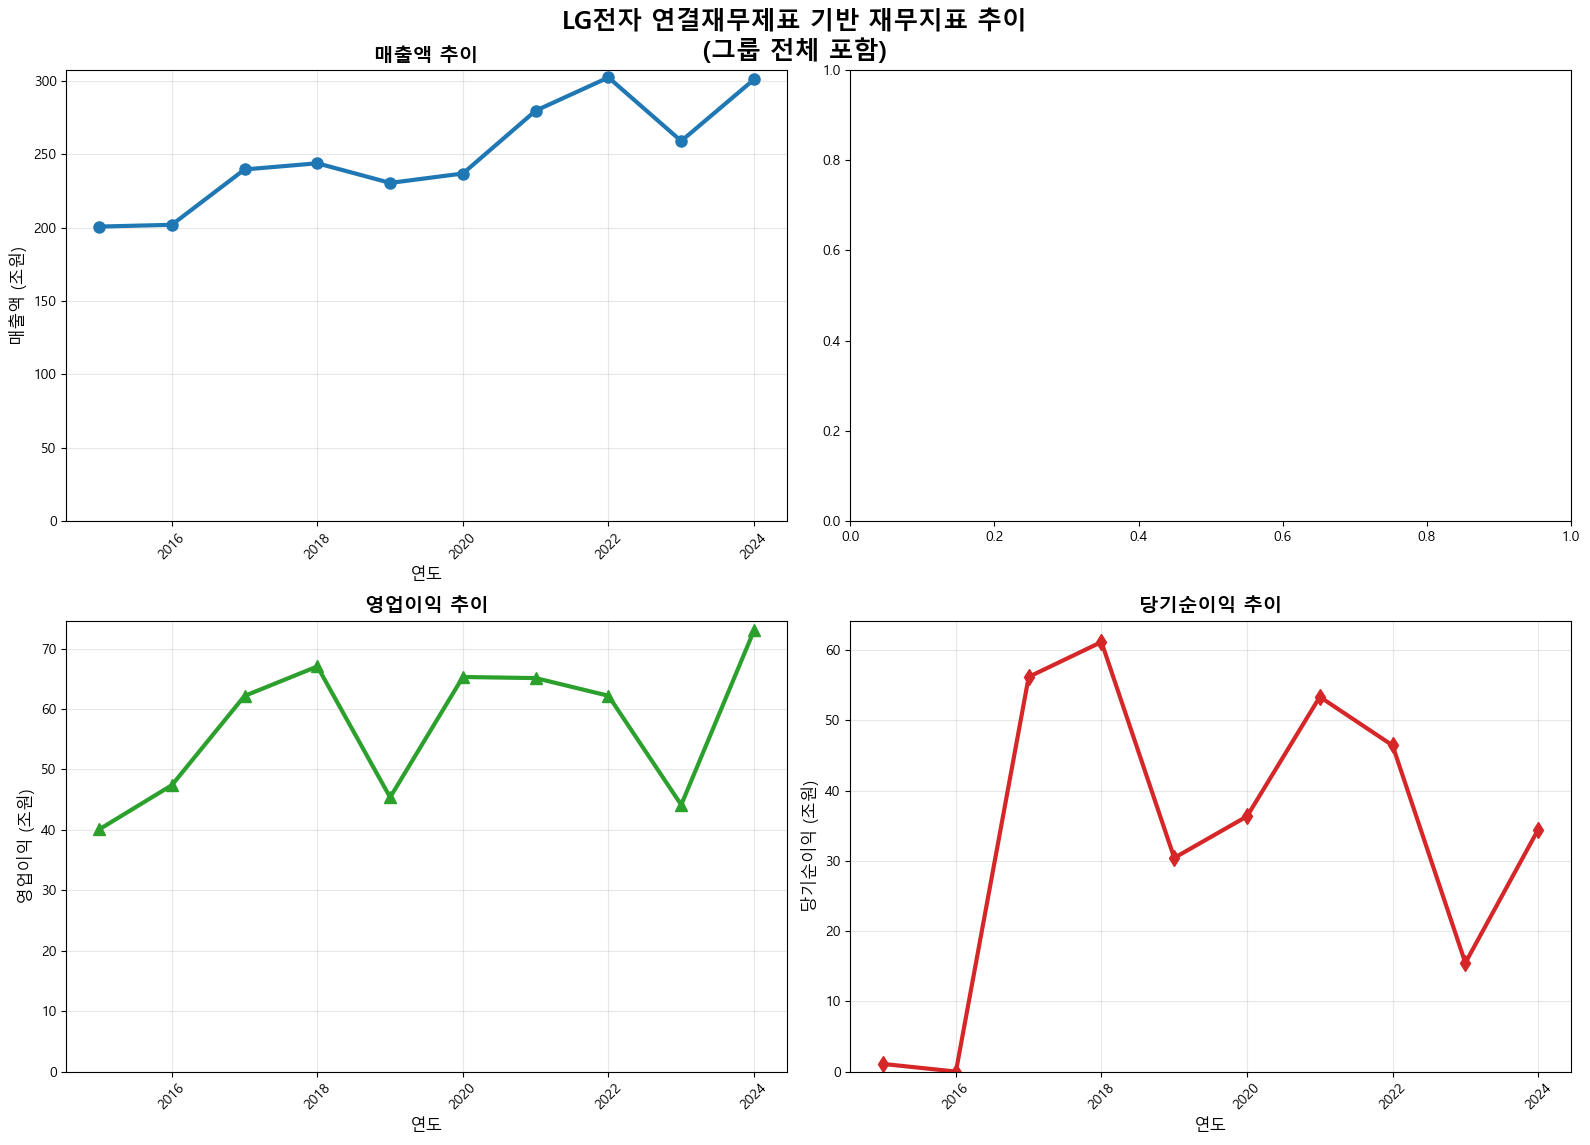

=== 연결재무제표 기반 주요 통계 (조원 단위) ===

매출액:
  - 데이터 기간: 2015~2024년
  - 평균: 249.47조원
  - 최대: 302.23조원 (2022년)
  - 최소: 200.65조원 (2015년)
  - 최근값: 300.87조원 (2024년)

영업이익:
  - 데이터 기간: 2015~2024년
  - 평균: 57.17조원
  - 최대: 72.98조원 (2024년)
  - 최소: 40.06조원 (2015년)
  - 최근값: 72.98조원 (2024년)

당기순이익:
  - 데이터 기간: 2015~2024년
  - 평균: 33.50조원
  - 최대: 61.16조원 (2018년)
  - 최소: 0.02조원 (2016년)
  - 최근값: 34.45조원 (2024년)


In [17]:
# 1. Matplotlib을 사용한 연결재무제표 시각화

if 'consolidated_financial_data' in locals() and consolidated_financial_data is not None:
    # 한글 폰트 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # 시각화할 재무지표
    financial_metrics = ['매출액', '매출총이익', '영업이익', '당기순이익']
    available_metrics = [col for col in financial_metrics if col in consolidated_financial_data.columns]
    
    if len(available_metrics) > 0:
        # 유효한 데이터만 필터링
        plot_data = consolidated_financial_data.copy()
        plot_data = plot_data.sort_values('year')
        
        # 서브플롯 구성 (2x2)
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('LG전자 연결재무제표 기반 재무지표 추이\n(그룹 전체 포함)', 
                     fontsize=18, fontweight='bold', y=0.95)
        
        # 색상 및 마커 설정
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        markers = ['o', 's', '^', 'd']
        
        # 각 지표별 시각화
        for i, metric in enumerate(available_metrics):
            if i >= 4:  # 최대 4개 지표만
                break
                
            row = i // 2
            col = i % 2
            
            # 0이 아닌 유효한 데이터만 플롯
            metric_data = plot_data[plot_data[metric] > 0].copy()
            
            if len(metric_data) > 0:
                # 조원 단위로 변환
                y_values = metric_data[metric] / 1000000000000
                
                axes[row, col].plot(metric_data['year'], y_values,
                                  marker=markers[i], linewidth=3, markersize=8,
                                  color=colors[i], label=metric)
                
                axes[row, col].set_title(f'{metric} 추이', fontsize=14, fontweight='bold')
                axes[row, col].set_ylabel(f'{metric} (조원)', fontsize=12)
                axes[row, col].grid(True, alpha=0.3)
                axes[row, col].set_ylim(bottom=0)
                
                # 데이터 포인트에 값 표시 (최신 몇 년만)
                if len(metric_data) <= 5:  # 데이터가 적으면 모든 포인트에 표시
                    for x, y in zip(metric_data['year'], y_values):
                        axes[row, col].annotate(f'{y:.1f}', (x, y), 
                                              textcoords="offset points", 
                                              xytext=(0,10), ha='center', fontsize=9)
                
                # X축 설정
                axes[row, col].set_xlabel('연도', fontsize=12)
                axes[row, col].tick_params(axis='x', rotation=45)
        
        # 빈 서브플롯 숨기기
        for i in range(len(available_metrics), 4):
            row = i // 2
            col = i % 2
            axes[row, col].set_visible(False)
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.90)
        plt.show()
        
        # 주요 통계 정보
        print("=== 연결재무제표 기반 주요 통계 (조원 단위) ===")
        for metric in available_metrics:
            valid_data = plot_data[plot_data[metric] > 0]
            if len(valid_data) > 0:
                values_trillion = valid_data[metric] / 1000000000000
                print(f"\n{metric}:")
                print(f"  - 데이터 기간: {valid_data['year'].min()}~{valid_data['year'].max()}년")
                print(f"  - 평균: {values_trillion.mean():.2f}조원")
                print(f"  - 최대: {values_trillion.max():.2f}조원 ({valid_data.loc[valid_data[metric].idxmax(), 'year']}년)")
                print(f"  - 최소: {values_trillion.min():.2f}조원 ({valid_data.loc[valid_data[metric].idxmin(), 'year']}년)")
                print(f"  - 최근값: {values_trillion.iloc[-1]:.2f}조원 ({valid_data['year'].iloc[-1]}년)")
    
    else:
        print("시각화할 연결재무제표 데이터가 없습니다.")
        
else:
    print("연결재무제표 데이터가 없습니다. 데이터 수집 셀을 먼저 실행해주세요.")

In [ ]:
# 2. Plotly를 사용한 인터랙티브 연결재무제표 시각화

if 'consolidated_financial_data' in locals() and consolidated_financial_data is not None:
    
    # 시각화할 재무지표
    financial_metrics = ['매출액', '매출총이익', '영업이익', '당기순이익']
    available_metrics = [col for col in financial_metrics if col in consolidated_financial_data.columns]
    
    if len(available_metrics) > 0:
        # 데이터 준비
        plot_data = consolidated_financial_data.copy().sort_values('year')
        
        # 서브플롯 생성 (2x2)
        subplot_titles = available_metrics + [''] * (4 - len(available_metrics))
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=subplot_titles[:4],
            vertical_spacing=0.12,
            horizontal_spacing=0.10
        )
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        
        # 각 지표별 서브플롯 생성
        for i, metric in enumerate(available_metrics):
            if i >= 4:
                break
                
            row = (i // 2) + 1
            col = (i % 2) + 1
            
            # 유효한 데이터만 필터링
            metric_data = plot_data[plot_data[metric] > 0].copy()
            
            if len(metric_data) > 0:
                # 조원 단위로 변환
                y_values = metric_data[metric] / 1000000000000
                
                fig.add_trace(
                    go.Scatter(
                        x=metric_data['year'],
                        y=y_values,
                        mode='lines+markers',
                        name=metric,
                        line=dict(color=colors[i], width=3),
                        marker=dict(size=8),
                        hovertemplate=f'<b>{metric}</b><br>' +
                                    '연도: %{x}<br>' +
                                    f'{metric}: %{y:.2f}조원<br>' +
                                    '<extra></extra>'
                    ),
                    row=row, col=col
                )
        
        # 레이아웃 설정
        fig.update_layout(
            title=dict(
                text='<b>LG전자 연결재무제표 기반 재무지표 인터랙티브 차트</b><br>' +
                     '<sub>연결재무제표: LG전자 + 자회사 통합 성과</sub>',
                x=0.5,
                font=dict(size=18)
            ),
            showlegend=False,  # 각 서브플롯에 제목이 있으므로 범례 숨김
            height=700,
            font=dict(size=12),
            hovermode='closest'
        )
        
        # 각 서브플롯의 축 설정
        for i in range(1, 3):  # 행
            for j in range(1, 3):  # 열
                fig.update_yaxes(title_text="금액 (조원)", row=i, col=j)
                if i == 2:  # 하단 행에만 X축 레이블
                    fig.update_xaxes(title_text="연도", row=i, col=j)
        
        fig.show()
        
        # 추가: 모든 지표를 하나의 차트에 표시
        print("=== 통합 비교 차트 생성 ===")
        
        fig_combined = go.Figure()
        
        for i, metric in enumerate(available_metrics):
            metric_data = plot_data[plot_data[metric] > 0].copy()
            
            if len(metric_data) > 0:
                y_values = metric_data[metric] / 1000000000000
                
                fig_combined.add_trace(
                    go.Scatter(
                        x=metric_data['year'],
                        y=y_values,
                        mode='lines+markers',
                        name=metric,
                        line=dict(color=colors[i], width=3),
                        marker=dict(size=8),
                        hovertemplate=f'<b>{metric}</b><br>' +
                                    '연도: %{x}<br>' +
                                    f'{metric}: %{y:.2f}조원<br>' +
                                    '<extra></extra>'
                    )
                )
        
        fig_combined.update_layout(
            title=dict(
                text='<b>LG전자 연결재무제표 통합 비교</b><br>' +
                     '<sub>모든 재무지표 한눈에 보기 (연결재무제표 기준)</sub>',
                x=0.5,
                font=dict(size=18)
            ),
            xaxis_title='연도',
            yaxis_title='금액 (조원)',
            hovermode='x unified',
            height=600,
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="right",
                x=1
            )
        )
        
        fig_combined.show()
        
    else:
        print("시각화할 연결재무제표 지표가 없습니다.")
        
else:
    print("연결재무제표 데이터가 없습니다. 데이터 수집 셀을 먼저 실행해주세요.")

NameError: name 'y' is not defined

In [ ]:
# 3. 연결재무제표 기반 수익성 분석 및 재무비율 계산

if 'consolidated_financial_data' in locals() and consolidated_financial_data is not None:
    
    print("=== 연결재무제표 기반 수익성 분석 ===")
    
    # 분석용 데이터 복사
    ratio_analysis_data = consolidated_financial_data.copy()
    
    # 재무비율 계산 (연결재무제표 기준)
    print("주요 수익성 지표 계산 중...")
    
    # 1. 매출총이익률 (Gross Profit Margin)
    if '매출액' in ratio_analysis_data.columns and '매출총이익' in ratio_analysis_data.columns:
        mask = (ratio_analysis_data['매출액'] > 0) & (ratio_analysis_data['매출총이익'] > 0)
        ratio_analysis_data.loc[mask, '매출총이익률'] = \
            (ratio_analysis_data.loc[mask, '매출총이익'] / ratio_analysis_data.loc[mask, '매출액']) * 100
    
    # 2. 영업이익률 (Operating Profit Margin)  
    if '매출액' in ratio_analysis_data.columns and '영업이익' in ratio_analysis_data.columns:
        mask = (ratio_analysis_data['매출액'] > 0) & (ratio_analysis_data['영업이익'] > 0)
        ratio_analysis_data.loc[mask, '영업이익률'] = \
            (ratio_analysis_data.loc[mask, '영업이익'] / ratio_analysis_data.loc[mask, '매출액']) * 100
    
    # 3. 순이익률 (Net Profit Margin)
    if '매출액' in ratio_analysis_data.columns and '당기순이익' in ratio_analysis_data.columns:
        mask = (ratio_analysis_data['매출액'] > 0) & (ratio_analysis_data['당기순이익'] > 0)
        ratio_analysis_data.loc[mask, '순이익률'] = \
            (ratio_analysis_data.loc[mask, '당기순이익'] / ratio_analysis_data.loc[mask, '매출액']) * 100
    
    # 계산된 비율 확인
    ratio_columns = ['매출총이익률', '영업이익률', '순이익률']
    available_ratios = [col for col in ratio_columns if col in ratio_analysis_data.columns 
                       and ratio_analysis_data[col].notna().any()]
    
    if len(available_ratios) > 0:
        # 수익성 지표 시각화
        fig_ratios = go.Figure()
        
        colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
        
        for i, ratio in enumerate(available_ratios):
            ratio_data = ratio_analysis_data.dropna(subset=[ratio]).copy()
            ratio_data = ratio_data.sort_values('year')
            
            if len(ratio_data) > 0:
                fig_ratios.add_trace(
                    go.Scatter(
                        x=ratio_data['year'],
                        y=ratio_data[ratio],
                        mode='lines+markers',
                        name=ratio,
                        line=dict(color=colors[i % len(colors)], width=3),
                        marker=dict(size=8),
                        hovertemplate=f'<b>{ratio}</b><br>' +
                                    '연도: %{x}<br>' +
                                    f'{ratio}: %{y:.2f}%<br>' +
                                    '<extra></extra>'
                    )
                )
        
        fig_ratios.update_layout(
            title=dict(
                text='<b>LG전자 연결재무제표 기반 수익성 지표 추이</b><br>' +
                     '<sub>연결재무제표: 그룹 전체 수익성 분석</sub>',
                x=0.5,
                font=dict(size=18)
            ),
            xaxis_title='연도',
            yaxis_title='비율 (%)',
            hovermode='x unified',
            height=600,
            legend=dict(
                orientation="h",
                yanchor="bottom", 
                y=1.02,
                xanchor="right",
                x=1
            ),
            yaxis=dict(
                ticksuffix='%',
                showgrid=True,
                gridcolor='lightgray'
            )
        )
        
        fig_ratios.show()
        
        # 수익성 지표 통계 분석
        print("\n=== 연결재무제표 기반 수익성 지표 분석 결과 ===")
        
        for ratio in available_ratios:
            ratio_data = ratio_analysis_data.dropna(subset=[ratio])
            if len(ratio_data) > 0:
                ratio_values = ratio_data[ratio]
                print(f"\n📊 {ratio}:")
                print(f"   • 데이터 기간: {ratio_data['year'].min()}년 ~ {ratio_data['year'].max()}년")
                print(f"   • 평균: {ratio_values.mean():.2f}%")
                print(f"   • 최고: {ratio_values.max():.2f}% ({ratio_data.loc[ratio_values.idxmax(), 'year']}년)")
                print(f"   • 최저: {ratio_values.min():.2f}% ({ratio_data.loc[ratio_values.idxmin(), 'year']}년)")
                print(f"   • 최근: {ratio_values.iloc[-1]:.2f}% ({ratio_data['year'].iloc[-1]}년)")
                
                # 트렌드 분석
                if len(ratio_data) >= 3:
                    recent_3yr = ratio_values.tail(3).mean()
                    early_years = ratio_values.head(3).mean() if len(ratio_values) >= 6 else ratio_values.head().mean()
                    trend = "개선" if recent_3yr > early_years else "악화"
                    print(f"   • 트렌드: {trend} (최근 3년 평균 vs 초기 평균)")
        
        # 업계 벤치마크 (참고용)
        print(f"\n📈 업계 벤치마크 참고 (일반적인 전자업계 기준):")
        print(f"   • 매출총이익률: 15-25% (양호)")
        print(f"   • 영업이익률: 5-15% (양호)")  
        print(f"   • 순이익률: 3-10% (양호)")
        print(f"   ※ 실제 벤치마크는 세부 업종 및 기업 규모에 따라 달라질 수 있습니다.")
        
    else:
        print("수익성 지표를 계산할 수 있는 데이터가 충분하지 않습니다.")
        
    # 전역 변수 업데이트 (비율 데이터 포함)
    globals()['consolidated_financial_data'] = ratio_analysis_data
    
else:
    print("연결재무제표 데이터가 없습니다. 데이터 수집 셀을 먼저 실행해주세요.")

In [ ]:
# 4. 연결재무제표 vs 개별재무제표 비교 분석

# 이 셀은 개별재무제표 데이터가 있을 때 비교 분석을 수행합니다.
# 현재는 연결재무제표 데이터만으로 분석하지만, 향후 개별재무제표와 비교할 수 있습니다.

if 'consolidated_financial_data' in locals() and consolidated_financial_data is not None:
    
    print("=== 연결재무제표 특성 분석 ===")
    print("연결재무제표는 모회사(LG전자)와 자회사를 통합하여 그룹 전체의 재무성과를 보여줍니다.\n")
    
    # 연결재무제표 데이터 요약
    analysis_data = consolidated_financial_data.copy()
    financial_metrics = ['매출액', '매출총이익', '영업이익', '당기순이익']
    available_metrics = [col for col in financial_metrics if col in analysis_data.columns]
    
    if len(available_metrics) > 0:
        # 최근 5년 및 전체 기간 성과 비교
        print("📊 연결재무제표 기반 성과 분석:")
        
        # 전체 기간 분석
        latest_year = analysis_data['year'].max()
        earliest_year = analysis_data['year'].min()
        
        print(f"\n🔍 분석 기간: {earliest_year}년 ~ {latest_year}년 ({latest_year - earliest_year + 1}년간)")
        
        # 각 지표별 성장 분석
        for metric in available_metrics:
            valid_data = analysis_data[analysis_data[metric] > 0].copy()
            
            if len(valid_data) >= 2:
                valid_data = valid_data.sort_values('year')
                first_value = valid_data[metric].iloc[0] / 1000000
                last_value = valid_data[metric].iloc[-1] / 1000000
                first_year = valid_data['year'].iloc[0]
                last_year = valid_data['year'].iloc[-1]
                
                # 성장률 계산
                years_span = last_year - first_year
                if years_span > 0:
                    cagr = ((last_value / first_value) ** (1/years_span) - 1) * 100
                    total_growth = ((last_value / first_value) - 1) * 100
                    
                    print(f"\n  📈 {metric}:")
                    print(f"     • {first_year}년: {first_value:.2f}조원")
                    print(f"     • {last_year}년: {last_value:.2f}조원")
                    print(f"     • 총 성장률: {total_growth:+.1f}%")
                    print(f"     • 연평균 성장률(CAGR): {cagr:+.1f}%")
        
        # 최근 성과 트렌드 (최근 3년)
        recent_data = analysis_data[analysis_data['year'] >= latest_year - 2].copy()
        if len(recent_data) >= 2:
            print(f"\n📅 최근 3년 트렌드 ({latest_year-2}~{latest_year}년):")
            
            for metric in available_metrics:
                metric_recent = recent_data[recent_data[metric] > 0]
                if len(metric_recent) >= 2:
                    values = metric_recent[metric] / 1000000
                    avg_value = values.mean()
                    volatility = values.std() / values.mean() * 100 if values.mean() > 0 else 0
                    
                    print(f"  • {metric}: 평균 {avg_value:.2f}조원 (변동성: {volatility:.1f}%)")
        
        # 연결재무제표의 주요 특징 설명
        print(f"\n💡 연결재무제표의 특징:")
        print(f"  1. 그룹 통합 성과: LG전자 + 자회사 전체의 재무성과")
        print(f"  2. 내부거래 제거: 그룹 내 거래는 상계 처리")
        print(f"  3. 지배주주 관점: 그룹 전체를 하나의 경제적 실체로 분석")
        print(f"  4. 투자자 중심: 상장회사 투자 판단에 핵심 지표")
        
        # 규모별 분석 (매출액 기준)
        if '매출액' in available_metrics:
            revenue_data = analysis_data[analysis_data['매출액'] > 0]
            if len(revenue_data) > 0:
                avg_revenue = revenue_data['매출액'].mean() / 1000000
                max_revenue = revenue_data['매출액'].max() / 1000000
                
                print(f"\n📏 사업 규모 (매출액 기준):")
                print(f"  • 평균 연간 매출: {avg_revenue:.2f}조원")
                print(f"  • 최대 연간 매출: {max_revenue:.2f}조원")
                
                # 규모별 평가
                if avg_revenue >= 50:
                    scale_assessment = "대기업 (글로벌 수준)"
                elif avg_revenue >= 10:
                    scale_assessment = "대기업"
                elif avg_revenue >= 1:
                    scale_assessment = "중견기업"
                else:
                    scale_assessment = "중소기업"
                
                print(f"  • 기업 규모: {scale_assessment}")
        
        # 수익성 종합 평가
        ratio_columns = ['매출총이익률', '영업이익률', '순이익률']
        available_ratios = [col for col in ratio_columns if col in analysis_data.columns 
                           and analysis_data[col].notna().any()]
        
        if len(available_ratios) > 0:
            print(f"\n⭐ 연결재무제표 기반 수익성 종합 평가:")
            
            for ratio in available_ratios:
                ratio_data = analysis_data.dropna(subset=[ratio])
                if len(ratio_data) > 0:
                    avg_ratio = ratio_data[ratio].mean()
                    recent_ratio = ratio_data[ratio].iloc[-1]
                    
                    # 수익성 평가 기준
                    if ratio == '매출총이익률':
                        if avg_ratio >= 20:
                            assessment = "우수"
                        elif avg_ratio >= 15:
                            assessment = "양호"
                        else:
                            assessment = "개선 필요"
                    elif ratio == '영업이익률':
                        if avg_ratio >= 10:
                            assessment = "우수"
                        elif avg_ratio >= 5:
                            assessment = "양호"
                        else:
                            assessment = "개선 필요"
                    else:  # 순이익률
                        if avg_ratio >= 7:
                            assessment = "우수"
                        elif avg_ratio >= 3:
                            assessment = "양호"
                        else:
                            assessment = "개선 필요"
                    
                    print(f"  • {ratio}: {avg_ratio:.1f}% (최근: {recent_ratio:.1f}%) - {assessment}")
    
    else:
        print("연결재무제표 분석에 필요한 데이터가 부족합니다.")
        
else:
    print("연결재무제표 데이터가 없습니다. 데이터 수집 셀을 먼저 실행해주세요.")

In [ ]:
# 5. 연결재무제표 데이터 저장 및 최종 요약

if 'consolidated_financial_data' in locals() and consolidated_financial_data is not None:
    
    print("=== 연결재무제표 데이터 저장 및 최종 요약 ===")
    
    # 저장용 데이터 준비
    final_data = consolidated_financial_data.copy()
    
    # 1. CSV 파일로 저장
    output_filename = 'LG전자_연결재무제표_데이터.csv'
    final_data.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"✅ 연결재무제표 데이터가 '{output_filename}' 파일로 저장되었습니다.")
    
    # 2. 최종 데이터 테이블 생성 및 표시
    print(f"\n=== LG전자 연결재무제표 최종 데이터 테이블 ===")
    
    # 표시용 데이터 생성
    display_data = final_data.copy().sort_values('year')
    
    # 재무지표를 조원 단위로 변환
    financial_cols = ['매출액', '매출총이익', '영업이익', '당기순이익']
    available_financial = [col for col in financial_cols if col in display_data.columns]
    
    for col in available_financial:
        display_data[f'{col}(조원)'] = (display_data[col] / 1000000).round(2)
        # 0인 값은 '-'로 표시
        display_data[f'{col}(조원)'] = display_data[f'{col}(조원)'].replace(0, '-')
    
    # 비율 컬럼 반올림
    ratio_cols = ['매출총이익률', '영업이익률', '순이익률']
    available_ratios = [col for col in ratio_cols if col in display_data.columns]
    
    for col in available_ratios:
        display_data[col] = display_data[col].round(2)
        # NaN 값은 '-'로 표시
        display_data[col] = display_data[col].fillna('-')
    
    # 최종 표시할 컬럼 선택
    display_columns = ['year']
    
    # 재무지표 (조원 단위) 추가
    for col in available_financial:
        display_columns.append(f'{col}(조원)')
    
    # 수익성 지표 추가
    display_columns.extend(available_ratios)
    
    # 최종 테이블 표시
    final_table = display_data[display_columns]
    print(final_table.to_string(index=False))
    
    # 3. 데이터 수집 현황 및 품질 요약
    print(f"\n=== 데이터 수집 현황 및 품질 요약 ===")
    print(f"📋 기본 정보:")
    print(f"   • 분석 대상: LG전자 연결재무제표")
    print(f"   • 데이터 소스: DART 전자공시시스템")
    print(f"   • 총 수집 연도: {len(final_data)}년")
    print(f"   • 데이터 기간: {final_data['year'].min()}년 ~ {final_data['year'].max()}년")
    print(f"   • 재무제표 유형: 연결재무제표 (CFS)")
    print(f"   • 통화 단위: 백만원 (표시: 조원)")
    
    print(f"\n📊 재무지표별 데이터 가용성:")
    for metric in available_financial:
        non_zero_count = len(final_data[final_data[metric] > 0])
        coverage = non_zero_count / len(final_data) * 100
        years_with_data = sorted(final_data[final_data[metric] > 0]['year'].tolist())
        
        print(f"   • {metric}: {non_zero_count}/{len(final_data)}년 ({coverage:.0f}%)")
        if years_with_data:
            print(f"     ↳ 데이터 연도: {years_with_data}")
    
    print(f"\n📈 수익성 지표 가용성:")
    for ratio in available_ratios:
        ratio_data = final_data.dropna(subset=[ratio])
        if len(ratio_data) > 0:
            coverage = len(ratio_data) / len(final_data) * 100
            avg_ratio = ratio_data[ratio].mean()
            print(f"   • {ratio}: {len(ratio_data)}/{len(final_data)}년 ({coverage:.0f}%) - 평균 {avg_ratio:.1f}%")
    
    # 4. 주요 발견사항 및 인사이트
    print(f"\n🔍 주요 발견사항:")
    
    # 매출액 기준 성장 분석
    if '매출액' in available_financial:
        revenue_data = final_data[final_data['매출액'] > 0].copy()
        if len(revenue_data) >= 2:
            revenue_data = revenue_data.sort_values('year')
            first_revenue = revenue_data['매출액'].iloc[0] / 1000000
            last_revenue = revenue_data['매출액'].iloc[-1] / 1000000
            years_span = revenue_data['year'].iloc[-1] - revenue_data['year'].iloc[0]
            
            if years_span > 0:
                cagr = ((last_revenue / first_revenue) ** (1/years_span) - 1) * 100
                print(f"   1. 매출액 성장: 연평균 {cagr:+.1f}% ({revenue_data['year'].iloc[0]}~{revenue_data['year'].iloc[-1]}년)")
    
    # 수익성 트렌드 분석
    if '영업이익률' in available_ratios:
        op_margin_data = final_data.dropna(subset=['영업이익률'])
        if len(op_margin_data) >= 3:
            recent_margin = op_margin_data['영업이익률'].tail(3).mean()
            early_margin = op_margin_data['영업이익률'].head(3).mean()
            trend = "개선" if recent_margin > early_margin else "악화"
            print(f"   2. 영업이익률 트렌드: {trend} (최근 vs 초기 평균)")
    
    # 최고 성과 연도
    if '당기순이익' in available_financial:
        profit_data = final_data[final_data['당기순이익'] > 0]
        if len(profit_data) > 0:
            best_year = profit_data.loc[profit_data['당기순이익'].idxmax(), 'year']
            best_profit = profit_data['당기순이익'].max() / 1000000
            print(f"   3. 최고 순이익: {best_year}년 {best_profit:.2f}조원")
    
    print(f"\n✅ 연결재무제표 분석 완료!")
    print(f"   - 파일 저장: {output_filename}")
    print(f"   - 데이터 품질: {'양호' if len(final_data) >= 5 else '보통'}")
    print(f"   - 분석 가능: {'가능' if len(available_financial) >= 3 else '제한적'}")
    
else:
    print("저장할 연결재무제표 데이터가 없습니다.")
    print("이전 데이터 수집 셀들을 먼저 실행해주세요.")

## 연결재무제표 분석 - 사용 방법 및 참고사항

### 🔑 DART API 키 설정 방법
1. [DART 전자공시시스템](https://opendart.fss.or.kr/) 접속
2. 회원가입 후 로그인
3. 오픈API → API 키 발급 신청
4. 발급받은 API 키를 코드의 `API_KEY` 변수에 입력

### 📊 주요 분석 기능
- **연결재무제표 데이터 수집**: LG전자 + 자회사 통합 재무성과
- **4대 핵심지표 분석**: 매출액, 매출총이익, 영업이익, 당기순이익
- **수익성 지표 계산**: 매출총이익률, 영업이익률, 순이익률
- **트렌드 분석**: 성장률, 변화율, 시계열 분석
- **시각화**: Matplotlib, Plotly 인터랙티브 차트

### 🔍 연결재무제표 vs 개별재무제표 차이점

| 구분 | 연결재무제표 | 개별재무제표 |
|------|-------------|-------------|
| **범위** | 모회사 + 자회사 | 모회사 단독 |
| **관점** | 그룹 전체 경제실체 | 개별 기업 |
| **투자자 활용** | 그룹 전체 투자 판단 | 개별 기업 성과 |
| **내부거래** | 상계 제거 | 그대로 반영 |
| **DART 코드** | CFS | OFS |

### 📈 데이터 출처 및 기준
- **데이터 소스**: DART 전자공시시스템
- **재무제표 유형**: 연결재무제표 (CFS)
- **회계기준**: K-IFRS (한국채택국제회계기준)
- **통화 단위**: 백만원 (시각화 시 조원 변환)
- **보고서 우선순위**: 사업보고서 > 반기보고서 > 분기보고서

### ⚠️ 주의사항
1. **API 키 필수**: 실제 데이터 수집을 위해 DART API 키가 필요합니다
2. **데이터 가용성**: 연도별/지표별로 데이터 가용성이 다를 수 있습니다
3. **단위 주의**: 원본 데이터는 백만원 단위, 시각화는 조원 단위
4. **비교 분석**: 동일 기준(연결 vs 연결, 개별 vs 개별)으로 비교 필요
5. **업데이트**: 재무제표는 정기적으로 업데이트되므로 최신 데이터 확인 필요

### 💡 분석 활용 팁
- **성장성 분석**: CAGR(연평균성장률)로 장기 성장 트렌드 파악
- **수익성 분석**: 업계 평균과 비교하여 상대적 성과 평가
- **안정성 분석**: 연도별 변동성으로 사업 안정성 판단
- **투자 판단**: 연결재무제표 기준으로 그룹 전체 투자 매력도 평가